<a href="https://colab.research.google.com/github/Anuska111/E-Commerce-Customer-Lifetime-Value-CLV-Segmentation/blob/main/E_Commerce_Customer_Lifetime_Value_(CLV)_%26_Segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
##Import Required Libraries
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
##Load Dataset
df = pd.read_excel("/content/online_retail_II.xlsx")

In [ ]:
##Dataset Check
df.head()

In [ ]:
df.tail()

In [ ]:
df.shape

In [ ]:
df.columns

In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:
#Data Cleaning
df.isnull().sum()

In [ ]:
df = df.dropna()

In [ ]:
df.duplicated().sum()

In [ ]:
df = df.drop_duplicates()

In [ ]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [ ]:

df = df[~df["Invoice"].astype(str).str.startswith("C")]
df = df[df["Quantity"] > 0]
df = df[df["Price"] > 0]

In [ ]:
print(df[df["Invoice"].astype(str).str.startswith("C")].shape)
print(df[df["Quantity"] < 0].shape)
print(df[df["Price"] <= 0].shape)

In [ ]:
df["Revenue"] = df["Quantity"] * df["Price"]

In [ ]:
df.head()

In [ ]:
#Feature Engineering (RFM)
snapshot_date = df["InvoiceDate"].max()

In [ ]:
rfm = df.groupby("Customer ID").agg({
    "Invoice": "nunique",
    "Revenue": "sum",
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days
}).reset_index()

In [ ]:
rfm.columns = [
    "CustomerID",
    "Frequency",
    "Monetary",
    "Recency"]

In [ ]:
rfm.head()

In [ ]:
#Exploratory Data Analysis (EDA)
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Revenue Distribution
sns.histplot(rfm["Monetary"])

plt.show()

In [ ]:
#Frequency Distribution
sns.boxplot(x=rfm["Frequency"])

plt.show()

In [ ]:
#Correlation
sns.heatmap(rfm.corr(), annot=True)

plt.show()

In [ ]:
#Data Scaling
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(

rfm[['Recency','Frequency','Monetary']]
)

In [ ]:
#Customer Segmentation
from sklearn.cluster import KMeans

In [ ]:
kmeans = KMeans(
n_clusters=4,
random_state=42
)
rfm["Cluster"] = kmeans.fit_predict(
scaled_data
)

In [ ]:
sns.scatterplot(
data=rfm,
x="Frequency",
y="Monetary",
hue="Cluster"
)
plt.show()

In [ ]:
#Evaluate Clustering
from sklearn.metrics import silhouette_score

In [ ]:
score = silhouette_score(
scaled_data,
rfm["Cluster"]
)
print(score)

In [ ]:
# Customer Segment Names

segment_names = {
    0: "At Risk Customers",
    1: "Active Customers"
}

rfm["CustomerSegment"] = rfm["Cluster"].map(segment_names)

print(rfm[["Cluster", "CustomerSegment"]].head())

In [ ]:
# Number of Customers in Each Segment

print(rfm["CustomerSegment"].value_counts())

In [ ]:
import matplotlib.pyplot as plt

rfm["CustomerSegment"].value_counts().plot(
    kind="bar",
    color=["tomato", "steelblue"]
)

plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

In [ ]:
# CREATE CLV
# Average Order Value
rfm["AvgOrderValue"] = rfm["Monetary"] / rfm["Frequency"]

# Customer Life Span
rfm["CustomerLifeSpan"] = rfm["Recency"] + 1

# Purchase Rate
rfm["PurchaseRate"] = (
    rfm["Frequency"] / rfm["CustomerLifeSpan"])


In [ ]:
# Customer Lifetime Value
rfm["CLV"] = (
    rfm["Frequency"]
    * rfm["AvgOrderValue"]
    * rfm["PurchaseRate"]
)

print(rfm[[
    "Recency",
    "Frequency",
    "Monetary",
    "AvgOrderValue",
    "PurchaseRate",
    "CLV"
]].head())

In [ ]:
# REMOVE OUTLIERS
Q1 = rfm["CLV"].quantile(0.25)
Q3 = rfm["CLV"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

rfm = rfm[
    (rfm["CLV"] >= lower) &
    (rfm["CLV"] <= upper)]


In [ ]:
# FEATURES & TARGET
rfm["LogFrequency"] = np.log1p(rfm["Frequency"])
rfm["LogRecency"] = np.log1p(rfm["Recency"])

X = rfm[
    [
        "Recency",
        "Frequency",
        "Monetary",
        "LogFrequency",
        "LogRecency"]]

y = rfm["CLV"]


In [ ]:
# TRAIN TEST SPLIT
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
# TRAIN MODEL
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)



RandomForestRegressor(n_estimators=200, random_state=42)

In [ ]:
# PREDICTION
prediction = model.predict(X_test)


In [ ]:
# EVALUATION
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error)
import numpy as np

rmse = np.sqrt(
    mean_squared_error(y_test, prediction))
r2 = r2_score(
    y_test,
    prediction)

mape = mean_absolute_percentage_error(
    y_test,
    prediction) * 100


In [ ]:
print("RMSE :", rmse)
print("R2 Score :", r2)
print("MAPE :", mape)

RMSE : 24.589711529869202
R2 Score : 0.9731112868655205
MAPE : 7.448089447638644


In [ ]:
print("y_test :", len(y_test))
print("prediction :", len(prediction))

y_test : 713
prediction : 713


In [ ]:
print(X.columns)

Index(['Recency', 'Frequency', 'Monetary', 'LogFrequency', 'LogRecency'], dtype='object')


Monetary        0.256719
LogFrequency    0.240411
Frequency       0.200707
LogRecency      0.153621
Recency         0.148542
dtype: float64


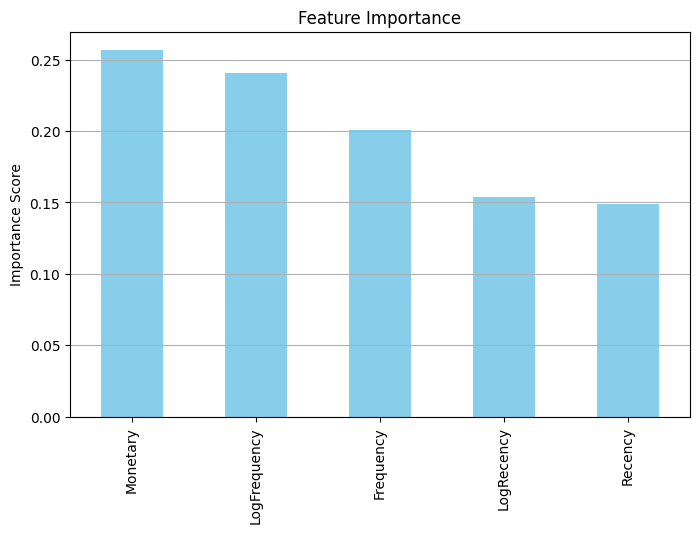

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importance)

plt.figure(figsize=(8,5))
importance.plot(kind="bar", color="skyblue")
plt.title("Feature Importance")
plt.ylabel("Importance Score")
plt.grid(axis="y")
plt.show()

In [ ]:
result = pd.DataFrame({
    "Actual CLV": y_test,
    "Predicted CLV": prediction})

result.head(10)

,Actual CLV,Predicted CLV
3020,2.287410,2.365845
221,12.039811,11.677404
2226,144.995769,153.520125
1635,141.696000,152.456740
3453,456.017143,388.012646
920,1.544643,4.882460
259,64.016000,63.709426
216,79.416562,81.383392
1692,49.131795,50.636746
1055,651.666667,659.070313


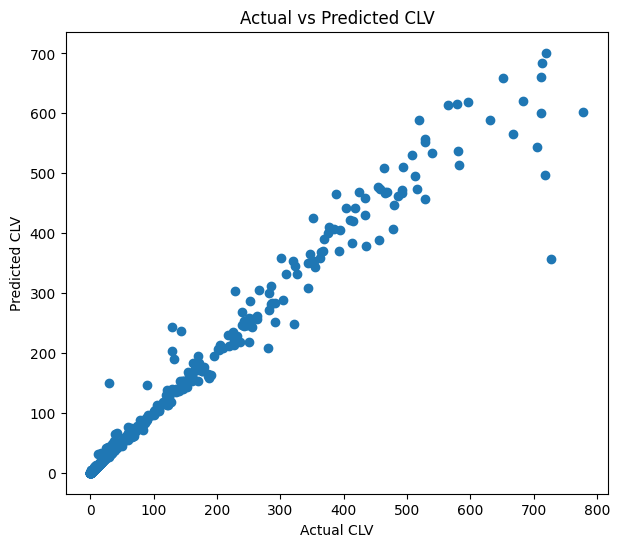

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7,6))
plt.scatter(y_test, prediction)
plt.xlabel("Actual CLV")
plt.ylabel("Predicted CLV")
plt.title("Actual vs Predicted CLV")
plt.show()

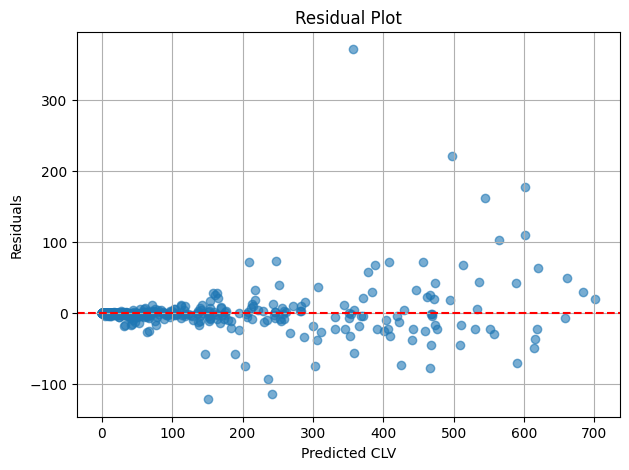

In [ ]:
#Residual Plot
import matplotlib.pyplot as plt

residuals = y_test - prediction

plt.figure(figsize=(7,5))

plt.scatter(prediction, residuals, alpha=0.6)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted CLV")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.grid(True)

plt.show()

In [ ]:
print(rfm["CLV"].describe())

count    3564.000000
mean       87.699353
std       154.327159
min         0.008240
25%         2.883529
50%        16.553558
75%        91.253967
max       780.186000
Name: CLV, dtype: float64


In [ ]:
import pandas as pd
import numpy as np

# User Input
recency = 10
frequency = 15
monetary = 25000   # Total amount spent by customer

# Create New Customer Features
new_customer = pd.DataFrame({
    "Recency": [recency],
    "Frequency": [frequency],
    "Monetary": [monetary],
    "LogFrequency": [np.log1p(frequency)],
    "LogRecency": [np.log1p(recency)]
})

# Predict CLV
predicted_clv = model.predict(new_customer)

print(f"Predicted Customer Lifetime Value (CLV): {predicted_clv[0]:.2f}")

Predicted Customer Lifetime Value (CLV): 743.03


In [ ]:
print(rfm["CLV"].describe())

count    3564.000000
mean       87.699353
std       154.327159
min         0.008240
25%         2.883529
50%        16.553558
75%        91.253967
max       780.186000
Name: CLV, dtype: float64


In [ ]:
##Dashboard (Streamlit)
#Save Model
import joblib
joblib.dump(model, "clv_model.pkl")
print("Model Saved Successfully")

Model Saved Successfully


In [ ]:
#Save RFM Dataset
rfm.to_csv("rfm.csv", index=False)

In [ ]:
##Dashboard Section
#Dashboard Heading
print("="*60)
print("E-Commerce Customer Dashboard")
print("="*60)

E-Commerce Customer Dashboard


In [ ]:
#Business Summary
print("Total Customers :", len(rfm))
print("Average CLV :", round(rfm["CLV"].mean(),2))
print("Maximum CLV :", round(rfm["CLV"].max(),2))
print("Minimum CLV :", round(rfm["CLV"].min(),2))

Total Customers : 3564
Average CLV : 87.7
Maximum CLV : 780.19
Minimum CLV : 0.01


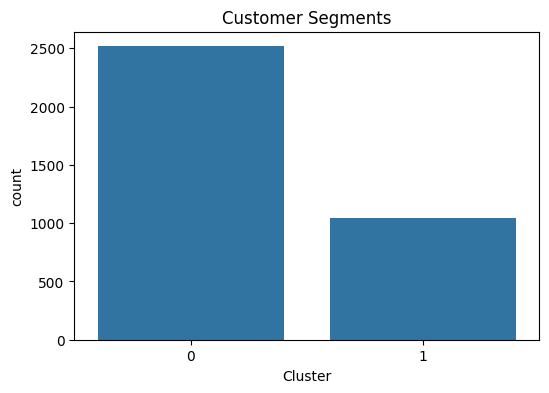

In [ ]:
#Cluster Distribution
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6,4))
sns.countplot(
    data=rfm,
    x="Cluster")
plt.title("Customer Segments")
plt.show()

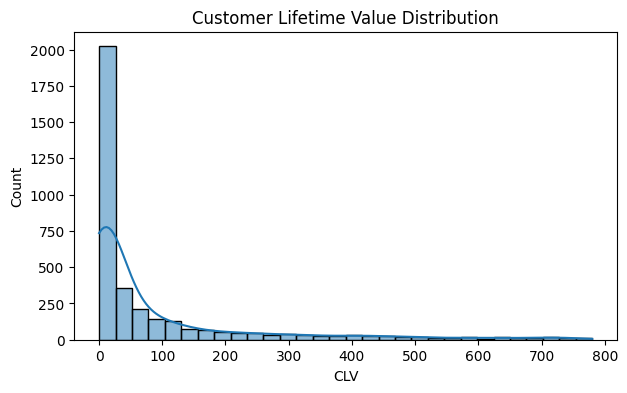

In [ ]:
#CLV Distribution
plt.figure(figsize=(7,4))
sns.histplot(
    rfm["CLV"],
    bins=30,
    kde=True)
plt.title("Customer Lifetime Value Distribution")
plt.show()

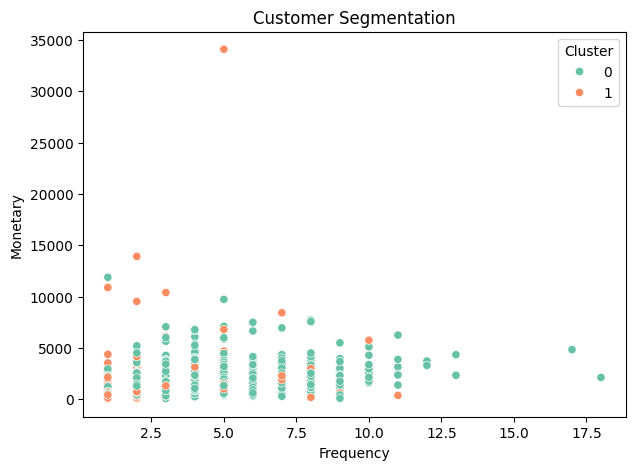

In [ ]:
#Customer Segmentation
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Cluster",
    palette="Set2")
plt.title("Customer Segmentation")
plt.show()

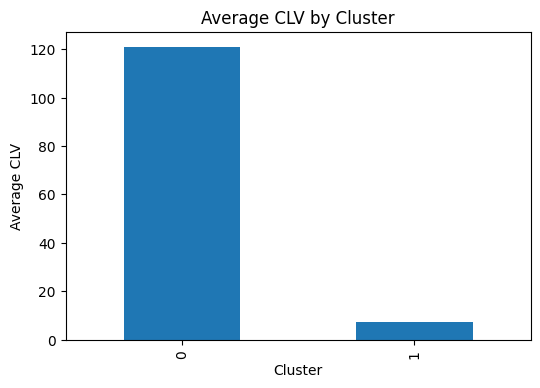

In [ ]:
#Average CLV by Cluster
cluster_clv = rfm.groupby("Cluster")["CLV"].mean()
cluster_clv.plot(
    kind="bar",
    figsize=(6,4))
plt.title("Average CLV by Cluster")
plt.ylabel("Average CLV")
plt.show()

In [ ]:
#Top 10 Customers
rfm.sort_values(
    by="CLV",
    ascending=False
).head(10)

,CustomerID,Frequency,Monetary,Recency,Cluster,CustomerSegment,AvgOrderValue,CustomerLifeSpan,PurchaseRate,CLV,LogFrequency,LogRecency
1688,14710.0,9,1300.31,14,0,At Risk Customers,144.478889,15,0.600000,780.186000,2.302585,2.708050
466,13037.0,9,3033.88,34,0,At Risk Customers,337.097778,35,0.257143,780.140571,2.302585,3.555348
4054,17929.0,8,2239.10,22,0,At Risk Customers,279.887500,23,0.347826,778.817391,2.197225,3.135494
4158,18069.0,6,2455.68,18,0,At Risk Customers,409.280000,19,0.315789,775.477895,1.945910,2.944439
1879,14963.0,7,1651.23,14,0,At Risk Customers,235.890000,15,0.466667,770.574000,2.079442,2.708050
1035,13823.0,5,2445.79,15,0,At Risk Customers,489.158000,16,0.312500,764.309375,1.791759,2.772589
66,12435.0,4,6096.04,31,0,At Risk Customers,1524.010000,32,0.125000,762.005000,1.609438,3.465736
1846,14918.0,7,4345.66,39,0,At Risk Customers,620.808571,40,0.175000,760.490500,2.079442,3.688879
336,12863.0,5,2271.35,14,0,At Risk Customers,454.270000,15,0.333333,757.116667,1.791759,2.708050
409,12967.0,2,2646.02,6,0,At Risk Customers,1323.010000,7,0.285714,756.005714,1.098612,1.945910


In [ ]:
#: Cluster Summary
rfm.groupby("Cluster").agg({
    "Recency":"mean",
    "Frequency":"mean",
    "Monetary":"mean",
    "CLV":"mean"})

,Recency,Frequency,Monetary,CLV
Cluster,,,,
0,50.467620,2.922527,989.349905,121.083661
1,241.976122,1.659981,593.540319,7.443092


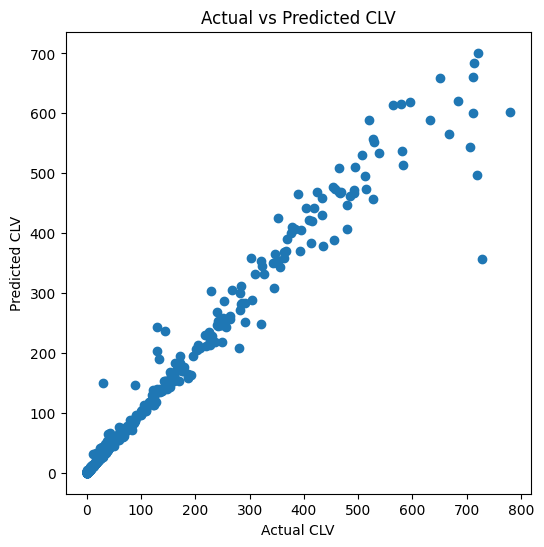

In [ ]:
plt.figure(figsize=(6,6))
plt.scatter(
    y_test,
    prediction)
plt.xlabel("Actual CLV")
plt.ylabel("Predicted CLV")
plt.title("Actual vs Predicted CLV")
plt.show()

In [ ]:
#Feature Importance
importance = pd.DataFrame({
     "Feature":X.columns,
     "Importance":model.feature_importances_})
importance.sort_values(
    by="Importance",
    ascending=False)

,Feature,Importance
2,Monetary,0.256719
3,LogFrequency,0.240411
1,Frequency,0.200707
4,LogRecency,0.153621
0,Recency,0.148542


In [ ]:
import pandas as pd
import numpy as np

# Customer Input
recency = 10
frequency = 5
monetary = 1200

# Log Features
log_frequency = np.log1p(frequency)
log_recency = np.log1p(recency)

# Create DataFrame (same columns as X)
new_customer = pd.DataFrame({
    "Recency": [recency],
    "Frequency": [frequency],
    "Monetary": [monetary],
    "LogFrequency": [log_frequency],
    "LogRecency": [log_recency]
})

# Predict CLV
predicted_clv = model.predict(new_customer)

print(f"Predicted Customer Lifetime Value (CLV): {predicted_clv[0]:.2f}")

Predicted Customer Lifetime Value (CLV): 549.63


In [ ]:
print(X.columns)
print(new_customer.columns)

Index(['Recency', 'Frequency', 'Monetary', 'LogFrequency', 'LogRecency'], dtype='object')
Index(['Recency', 'Frequency', 'Monetary', 'LogFrequency', 'LogRecency'], dtype='object')


In [ ]:
print("========== BUSINESS RECOMMENDATIONS ==========\n")

print("High Value Customers")
print("- Premium Offers")
print("- Loyalty Rewards")
print("- Exclusive Discounts\n")

print("Regular Customers")
print("- Personalized Recommendations")
print("- Email Marketing")
print("- Cross Selling\n")

print("At Risk Customers")
print("- Win-back Campaigns")
print("- Coupons")
print("- Reminder Emails")

========== BUSINESS RECOMMENDATIONS ==========

High Value Customers
- Premium Offers
- Loyalty Rewards
- Exclusive Discounts

Regular Customers
- Personalized Recommendations
- Email Marketing
- Cross Selling

At Risk Customers
- Win-back Campaigns
- Coupons
- Reminder Emails


In [ ]:
import joblib

joblib.dump(model, "clv_model.pkl")

['clv_model.pkl']

In [ ]:
from sklearn.model_selection import cross_val_score

# Perform cross-validation
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')
rmse_scores = np.sqrt(-cv_scores)

print("Cross-validation RMSE scores:", rmse_scores)
print("Average RMSE:", rmse_scores.mean())


Cross-validation RMSE scores: [27.92587756 28.70174093 37.16158629 24.15290388 20.79888701]
Average RMSE: 27.748199133243453
